In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd

from dap_job_quality import PROJECT_DIR

In [2]:
labelled_data = pd.read_csv(PROJECT_DIR / "inputs/labelled/Mapping evaluation - v2.csv", index_col=0)
lookup = pd.read_csv(PROJECT_DIR / "inputs/keyword_lookup - v4.csv")

In [3]:
labelled_data.head()

,id,chunk,sentence,span,target_phrase,subcategory,similarity,Correct?,COMP,LEAVE,SPONSORSHIP,FLEX_HOURS,FLEX_LOC,HOURS,CONTRACT,L&D,CAREER,PERKS,SOCIAL,OTHER
0,45332364,NaN,Basic entitlement is 30.0 days (pro rata for h...,['Basic entitlement is 30.0 days (pro rata for...,flexible working hours,FLEX_HOURS,0.421002,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,45332364,NaN,Employee benefit discount scheme Access to our...,"['Employee benefit discount scheme', 'Access t...",pension,COMP,0.364270,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN
2,45332364,NaN,Hours 38 per week Benefits Extensive access a...,"['Hours 38 per week', 'Extensive access and su...",flexible working hours,FLEX_HOURS,0.532661,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN
8,45338109,NaN,Most of the colleagues hold 1st class degrees ...,[' You will be given a training program when y...,learning & development,L&D,0.334314,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN
10,45338109,NaN,You will have the chance to branch off into di...,['chance to branch off into different areas on...,career progression,CAREER,0.472419,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN


In [4]:
lookup.head()

,dimension,subcategory,target_phrase,Notes
0,pay and benefits,COMP,pension,NaN
1,pay and benefits,COMP,bonus,NaN
2,pay and benefits,COMP,salary,NaN
3,pay and benefits,COMP,compensation,NaN
4,pay and benefits,COMP,pay,NaN


In [5]:
lookup['subcategory'].value_counts(normalize=True)

subcategory
FLEX_HOURS              0.129032
HOURS                   0.129032
COMP                    0.112903
PERKS                   0.096774
CONTRACT                0.064516
LEAVE                   0.064516
SOCIAL                  0.064516
CARING                  0.048387
REWARD                  0.032258
L&D                     0.032258
CAREER                  0.032258
FLEX_LOC                0.032258
SENSE OF PURPOSE        0.032258
OVERTIME                0.016129
M_HEALTH                0.016129
DISABILITY              0.016129
SPONSORSHIP             0.016129
SHIFT                   0.016129
AUTONOMY                0.016129
VOICE REPRESENTATION    0.016129
HEALTH                  0.016129
Name: proportion, dtype: float64

In [6]:
labelled_data['subcategory'].value_counts(normalize=True)

subcategory
FLEX_HOURS          0.219178
L&D                 0.136986
CAREER              0.130137
PERKS               0.123288
COMP                0.109589
HOURS               0.075342
CONTRACT            0.061644
SOCIAL              0.054795
LEAVE               0.047945
CARING              0.027397
REWARD              0.006849
SENSE OF PURPOSE    0.006849
Name: proportion, dtype: float64

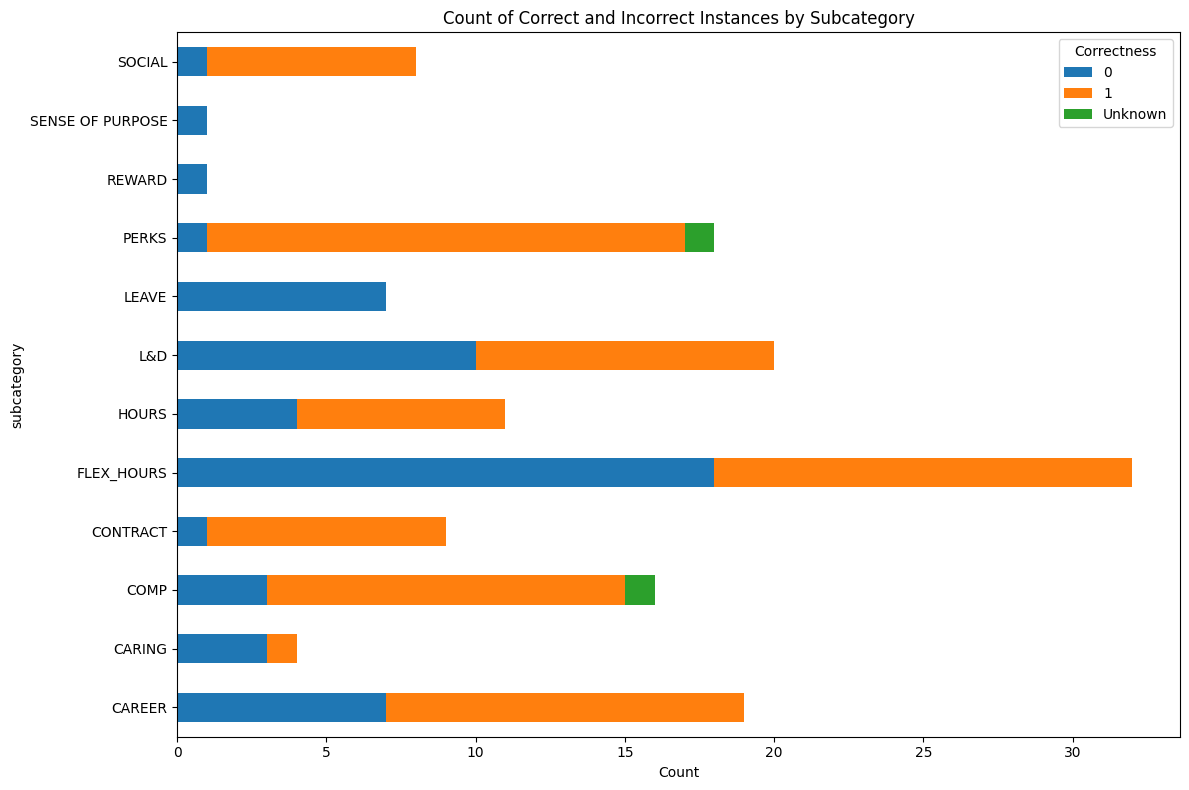

In [7]:

# Ensure the 'Correct?' column is correctly labeled and fix any issues
labelled_data['Correct?'] = labelled_data['Correct?'].replace({0: 'Incorrect', 1: 'Correct', '?': 'Unknown'})


# Calculate the count of correct and incorrect instances
count_correctness = labelled_data.groupby(['subcategory', 'Correct?']).size().reset_index(name='count')

# Pivot the table to have 'subcategory' as index and 'Correct?' as columns
count_correctness_pivot = count_correctness.pivot(index='subcategory', columns='Correct?', values='count').fillna(0)

# Plotting the count of correct and incorrect instances by subcategory
count_correctness_pivot.plot(kind='barh', stacked=True, figsize=(12, 8))
plt.title('Count of Correct and Incorrect Instances by Subcategory')
# plt.xlabel('Subcategory')
plt.xlabel('Count')
# plt.xticks(rotation=45)
plt.legend(title='Correctness')
plt.tight_layout()

# Save the plot as a file with bbox_inches='tight'
plt.savefig('count_correctness_by_subcategory.png', bbox_inches='tight')
plt.show()

In [8]:
# Calculate the mean similarity score for each subcategory and correctness
mean_similarity = labelled_data.groupby(['subcategory', 'Correct?'])['similarity'].mean().reset_index()

mean_similarity

,subcategory,Correct?,similarity
0,CAREER,0,0.400012
1,CAREER,1,0.501137
2,CARING,0,0.349892
3,CARING,1,0.318712
4,COMP,0,0.364411
5,COMP,1,0.411549
6,COMP,Unknown,0.329678
7,CONTRACT,0,0.235151
8,CONTRACT,1,0.528031
9,FLEX_HOURS,0,0.432030


In [19]:
correct_mean_cosine = labelled_data[labelled_data['Correct?']=='1']['similarity'].mean()
correct_mean_cosine

0.5043738782080459

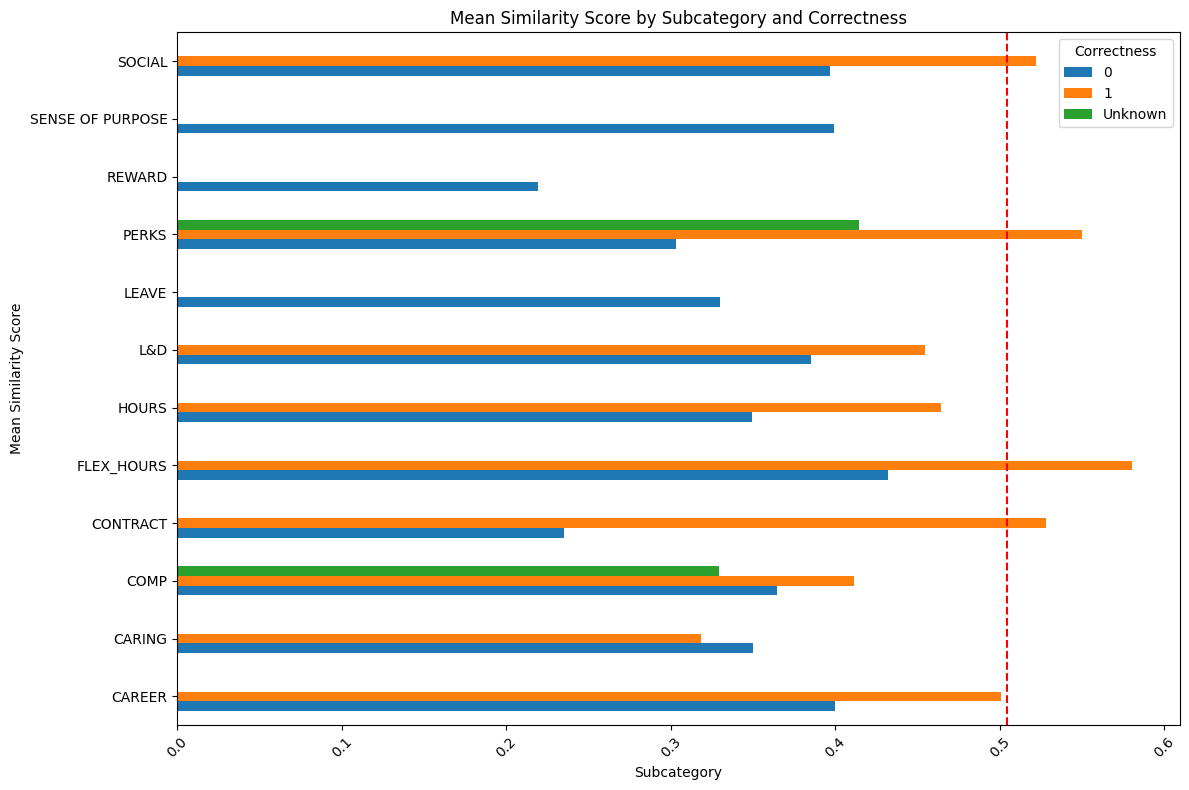

In [20]:
pivot_df = mean_similarity.pivot(index='subcategory', columns='Correct?', values='similarity').fillna(0)

# Plotting the bar plot
pivot_df.plot(kind='barh', figsize=(12, 8), stacked=False)
plt.axvline(x=correct_mean_cosine, color='red', linestyle='--')
plt.title('Mean Similarity Score by Subcategory and Correctness')
plt.xlabel('Subcategory')
plt.ylabel('Mean Similarity Score')
plt.xticks(rotation=45)
plt.legend(title='Correctness')
plt.tight_layout()

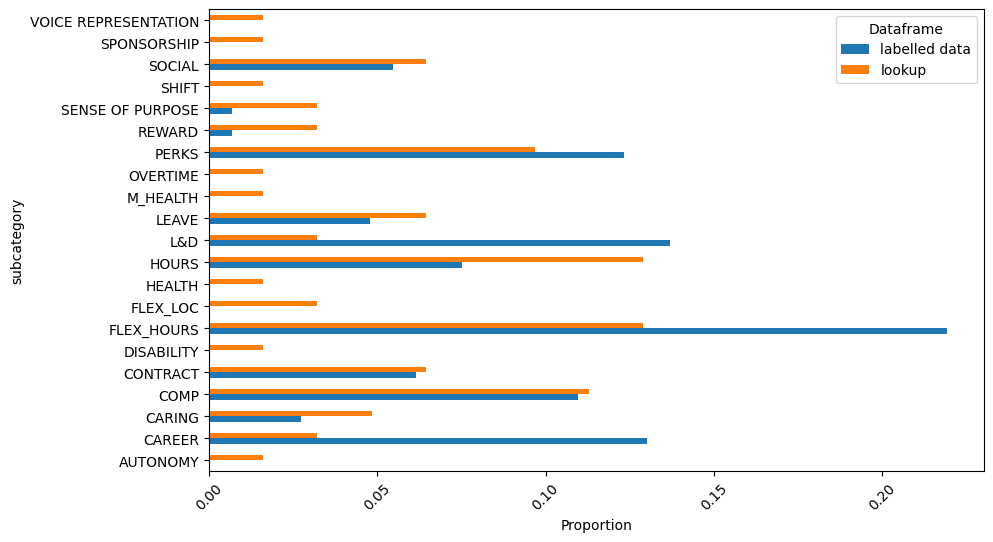

In [23]:
# Calculate proportional representation of each level of 'subcategory' in each dataframe
proportions_data = labelled_data['subcategory'].value_counts(normalize=True).sort_index()
proportions_lookup = lookup['subcategory'].value_counts(normalize=True).sort_index()

# Combine the proportions into a single dataframe for plotting
proportions = pd.DataFrame({'labelled data': proportions_data, 'lookup': proportions_lookup}).fillna(0)

# Plotting the comparison
proportions.plot(kind='barh', figsize=(10, 6))
# plt.title('Proportional Representation of Subcategories')
plt.xlabel('Proportion')
# plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(title='Dataframe')
plt.savefig('proportional_representation.png', bbox_inches='tight')
plt.show()